In [ ]:
import pandas as pd
import numpy as np


In [ ]:
cd /content

/content


In [ ]:
!git clone https://github.com/MahmudulAlam/Complete-Blood-Cell-Count-Dataset.git

fatal: destination path 'Complete-Blood-Cell-Count-Dataset' already exists and is not an empty directory.


In [ ]:
!git clone https://github.com/Shenggan/BCCD_Dataset.git

fatal: destination path 'BCCD_Dataset' already exists and is not an empty directory.


In [ ]:
!ls


BCCD_Dataset  Complete-Blood-Cell-Count-Dataset  merged_BCCD  sample_data


In [ ]:
!mkdir -p /content/merged_BCCD/{train,val,test}/{images,annotations}

In [ ]:
import os, shutil
import xml.etree.ElementTree as ET

def fix_xml_filename(xml_path, new_filename):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    root.find("filename").text = new_filename
    tree.write(xml_path)

def copy_with_prefix(img_dir, ann_dir, out_img, out_ann, prefix):
    for img in os.listdir(img_dir):
        if not img.endswith(".jpg"):
            continue

        xml = img.replace(".jpg", ".xml")
        new_img = f"{prefix}_{img}"
        new_xml = f"{prefix}_{xml}"

        shutil.copy(os.path.join(img_dir, img),
                    os.path.join(out_img, new_img))
        shutil.copy(os.path.join(ann_dir, xml),
                    os.path.join(out_ann, new_xml))

        fix_xml_filename(os.path.join(out_ann, new_xml), new_img)

def merge_using_txt(txt_file, img_dir, ann_dir, out_img, out_ann, prefix):
    with open(txt_file) as f:
        ids = [line.strip() for line in f]

    for img_id in ids:
        img = img_id + ".jpg"
        xml = img_id + ".xml"

        new_img = f"{prefix}_{img}"
        new_xml = f"{prefix}_{xml}"

        shutil.copy(os.path.join(img_dir, img),
                    os.path.join(out_img, new_img))
        shutil.copy(os.path.join(ann_dir, xml),
                    os.path.join(out_ann, new_xml))

        fix_xml_filename(os.path.join(out_ann, new_xml), new_img)


In [ ]:
base = "/content/Complete-Blood-Cell-Count-Dataset"

copy_with_prefix(f"{base}/Training/Images",
                 f"{base}/Training/Annotations",
                 "/content/merged_BCCD/train/images",
                 "/content/merged_BCCD/train/annotations",
                 "A")

copy_with_prefix(f"{base}/Validation/Images",
                 f"{base}/Validation/Annotations",
                 "/content/merged_BCCD/val/images",
                 "/content/merged_BCCD/val/annotations",
                 "A")

copy_with_prefix(f"{base}/Testing/Images",
                 f"{base}/Testing/Annotations",
                 "/content/merged_BCCD/test/images",
                 "/content/merged_BCCD/test/annotations",
                 "A")


In [ ]:
base = "/content/BCCD_Dataset/BCCD"

merge_using_txt(f"{base}/ImageSets/Main/train.txt",
                f"{base}/JPEGImages",
                f"{base}/Annotations",
                "/content/merged_BCCD/train/images",
                "/content/merged_BCCD/train/annotations",
                "B")

merge_using_txt(f"{base}/ImageSets/Main/val.txt",
                f"{base}/JPEGImages",
                f"{base}/Annotations",
                "/content/merged_BCCD/val/images",
                "/content/merged_BCCD/val/annotations",
                "B")

merge_using_txt(f"{base}/ImageSets/Main/test.txt",
                f"{base}/JPEGImages",
                f"{base}/Annotations",
                "/content/merged_BCCD/test/images",
                "/content/merged_BCCD/test/annotations",
                "B")


In [ ]:
for split in ["train", "val", "test"]:
    print(split,
          len(os.listdir(f"/content/merged_BCCD/{split}/images")),
          len(os.listdir(f"/content/merged_BCCD/{split}/annotations")))

train 1010 1010
val 147 147
test 132 132


In [ ]:
import os
import xml.etree.ElementTree as ET

IMG_DIR = "/content/merged_BCCD/train/images"
ANN_DIR = "/content/merged_BCCD/train/annotations"

images = sorted([f for f in os.listdir(IMG_DIR) if f.endswith(".jpg")])

for idx, img_name in enumerate(images, start=1):
    new_id = f"IM_{idx:06d}"

    old_img_path = os.path.join(IMG_DIR, img_name)
    old_xml_path = os.path.join(ANN_DIR, img_name.replace(".jpg", ".xml"))

    new_img_name = new_id + ".jpg"
    new_xml_name = new_id + ".xml"

    new_img_path = os.path.join(IMG_DIR, new_img_name)
    new_xml_path = os.path.join(ANN_DIR, new_xml_name)

    # Rename image
    os.rename(old_img_path, new_img_path)

    # Update XML
    tree = ET.parse(old_xml_path)
    root = tree.getroot()
    root.find("filename").text = new_img_name

    # Save renamed XML
    tree.write(new_xml_path)
    os.remove(old_xml_path)

print("✅ Images and annotations renamed sequentially")


✅ Images and annotations renamed sequentially


In [ ]:
import os
import cv2
import numpy as np
import xml.etree.ElementTree as ET

IMG_DIR = "/content/merged_BCCD/train/images"
ANN_DIR = "/content/merged_BCCD/train/annotations"
MASK_DIR = "/content/merged_BCCD/train/masks"

os.makedirs(MASK_DIR, exist_ok=True)

for xml_file in os.listdir(ANN_DIR):
    if not xml_file.endswith(".xml"):
        continue

    tree = ET.parse(os.path.join(ANN_DIR, xml_file))
    root = tree.getroot()

    img_name = root.find("filename").text
    img_path = os.path.join(IMG_DIR, img_name)

    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    mask = np.zeros((h, w), dtype=np.uint8)
    instance_id = 1

    for obj in root.findall("object"):
        bbox = obj.find("bndbox")
        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)

        mask[ymin:ymax, xmin:xmax] = instance_id
        instance_id += 1

    out_name = img_name.replace(".jpg", ".png")
    cv2.imwrite(os.path.join(MASK_DIR, out_name), mask)


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

mask_path = "/content/merged_BCCD/train/masks/IM_000001.png"
mask = cv2.imread(mask_path, 0)

print("Unique IDs:", np.unique(mask))
print("Non-zero pixels:", np.count_nonzero(mask))
print("Mask shape:", mask.shape)


Unique IDs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
Non-zero pixels: 203700
Mask shape: (480, 640)


In [ ]:
import os
import cv2
import numpy as np
import xml.etree.ElementTree as ET

IMG_DIR = "/content/merged_BCCD/test/images"
ANN_DIR = "/content/merged_BCCD/test/annotations"
MASK_DIR = "/content/merged_BCCD/test/masks"

os.makedirs(MASK_DIR, exist_ok=True)

for xml_file in os.listdir(ANN_DIR):
    if not xml_file.endswith(".xml"):
        continue

    tree = ET.parse(os.path.join(ANN_DIR, xml_file))
    root = tree.getroot()

    img_name = root.find("filename").text
    img_path = os.path.join(IMG_DIR, img_name)

    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    mask = np.zeros((h, w), dtype=np.uint8)
    instance_id = 1

    for obj in root.findall("object"):
        bbox = obj.find("bndbox")
        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)

        mask[ymin:ymax, xmin:xmax] = instance_id
        instance_id += 1

    out_name = img_name.replace(".jpg", ".png")
    cv2.imwrite(os.path.join(MASK_DIR, out_name), mask)


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

mask_path = "/content/merged_BCCD/test/masks/A_BloodImage_00339.png"
mask = cv2.imread(mask_path, 0)

print("Unique IDs:", np.unique(mask))
print("Non-zero pixels:", np.count_nonzero(mask))
print("Mask shape:", mask.shape)

Unique IDs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]
Non-zero pixels: 214843
Mask shape: (480, 640)


In [ ]:
c

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

mask_path = "/content/merged_BCCD/val/masks/A_BloodImage_00002.png"
mask = cv2.imread(mask_path, 0)

print("Unique IDs:", np.unique(mask))
print("Non-zero pixels:", np.count_nonzero(mask))
print("Mask shape:", mask.shape)

Unique IDs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
Non-zero pixels: 178726
Mask shape: (480, 640)


In [ ]:
import os
import cv2
import numpy as np

# 1. Update the directories for each split (train, val, and test)
MASK_DIR = "/content/merged_BCCD/train/masks"
DIST_DIR = "/content/merged_BCCD/train/distances"
os.makedirs(DIST_DIR, exist_ok=True)

for mask_file in os.listdir(MASK_DIR):
    if not mask_file.endswith(".png"):
        continue

    # Load the instance mask
    mask = cv2.imread(os.path.join(MASK_DIR, mask_file), 0)

    # 2. Convert instance mask to a single binary mask (1 for any cell, 0 for background)
    # This ensures distance is calculated to the actual cell edge, not the center
    binary_mask = (mask > 0).astype(np.uint8)

    # 3. Apply the Euclidean Distance Transform (EDT)
    # cv2.DIST_L2 = Euclidean Distance
    # mask size 5 = higher precision mask for the calculation
    dist_map = cv2.distanceTransform(binary_mask, cv2.DIST_L2, 5)

    # 4. Normalization (Per-image)
    # Using per-image normalization (0 to 1) makes the signal much stronger
    # for the model to learn compared to global diagonal normalization.
    if dist_map.max() > 0:
        dist_map = dist_map / dist_map.max()

    # Save as .npy
    out_file = mask_file.replace(".png", "_dist.npy")
    np.save(os.path.join(DIST_DIR, out_file), dist_map)

print("✅ Distance maps successfully generated using EDT (Euclidean Distance Transform)")

✅ Distance maps successfully generated using EDT (Euclidean Distance Transform)


In [ ]:
import numpy as np

d = np.load("/content/merged_BCCD/train/distances/IM_000001_dist.npy")

print("Min:", d.min())
print("Max:", d.max())
print("Mean:", d.mean())
print("Non-zero pixels:", np.count_nonzero(d))
print("Shape:", d.shape)


Min: 0.0
Max: 1.0
Mean: 0.16388507
Non-zero pixels: 203700
Shape: (480, 640)


In [ ]:
import os
import cv2
import numpy as np

# 1. Update the directories for each split (train, val, and test)
MASK_DIR = "/content/merged_BCCD/test/masks"
DIST_DIR = "/content/merged_BCCD/test/distances"
os.makedirs(DIST_DIR, exist_ok=True)

for mask_file in os.listdir(MASK_DIR):
    if not mask_file.endswith(".png"):
        continue

    # Load the instance mask
    mask = cv2.imread(os.path.join(MASK_DIR, mask_file), 0)

    # 2. Convert instance mask to a single binary mask (1 for any cell, 0 for background)
    # This ensures distance is calculated to the actual cell edge, not the center
    binary_mask = (mask > 0).astype(np.uint8)

    # 3. Apply the Euclidean Distance Transform (EDT)
    # cv2.DIST_L2 = Euclidean Distance
    # mask size 5 = higher precision mask for the calculation
    dist_map = cv2.distanceTransform(binary_mask, cv2.DIST_L2, 5)

    # 4. Normalization (Per-image)
    # Using per-image normalization (0 to 1) makes the signal much stronger
    # for the model to learn compared to global diagonal normalization.
    if dist_map.max() > 0:
        dist_map = dist_map / dist_map.max()

    # Save as .npy
    out_file = mask_file.replace(".png", "_dist.npy")
    np.save(os.path.join(DIST_DIR, out_file), dist_map)

print("✅ Distance maps successfully generated using EDT (Euclidean Distance Transform)")

✅ Distance maps successfully generated using EDT (Euclidean Distance Transform)


In [ ]:
import numpy as np

d = np.load("/content/merged_BCCD/test/distances/A_BloodImage_00339_dist.npy")

print("Min:", d.min())
print("Max:", d.max())
print("Mean:", d.mean())
print("Non-zero pixels:", np.count_nonzero(d))
print("Shape:", d.shape)


Min: 0.0
Max: 1.0
Mean: 0.19906975
Non-zero pixels: 214843
Shape: (480, 640)


In [ ]:
import os
import cv2
import numpy as np

# 1. Update the directories for each split (train, val, and test)
MASK_DIR = "/content/merged_BCCD/val/masks"
DIST_DIR = "/content/merged_BCCD/val/distances"
os.makedirs(DIST_DIR, exist_ok=True)

for mask_file in os.listdir(MASK_DIR):
    if not mask_file.endswith(".png"):
        continue

    # Load the instance mask
    mask = cv2.imread(os.path.join(MASK_DIR, mask_file), 0)

    # 2. Convert instance mask to a single binary mask (1 for any cell, 0 for background)
    # This ensures distance is calculated to the actual cell edge, not the center
    binary_mask = (mask > 0).astype(np.uint8)

    # 3. Apply the Euclidean Distance Transform (EDT)
    # cv2.DIST_L2 = Euclidean Distance
    # mask size 5 = higher precision mask for the calculation
    dist_map = cv2.distanceTransform(binary_mask, cv2.DIST_L2, 5)

    # 4. Normalization (Per-image)
    # Using per-image normalization (0 to 1) makes the signal much stronger
    # for the model to learn compared to global diagonal normalization.
    if dist_map.max() > 0:
        dist_map = dist_map / dist_map.max()

    # Save as .npy
    out_file = mask_file.replace(".png", "_dist.npy")
    np.save(os.path.join(DIST_DIR, out_file), dist_map)

print("✅ Distance maps successfully generated using EDT (Euclidean Distance Transform)")

✅ Distance maps successfully generated using EDT (Euclidean Distance Transform)


In [ ]:
import numpy as np

d = np.load("/content/merged_BCCD/val/distances/A_BloodImage_00002_dist.npy")

print("Min:", d.min())
print("Max:", d.max())
print("Mean:", d.mean())
print("Non-zero pixels:", np.count_nonzero(d))
print("Shape:", d.shape)


Min: 0.0
Max: 1.0
Mean: 0.18635467
Non-zero pixels: 178726
Shape: (480, 640)


Unique values: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
Non-zero pixels: 203700


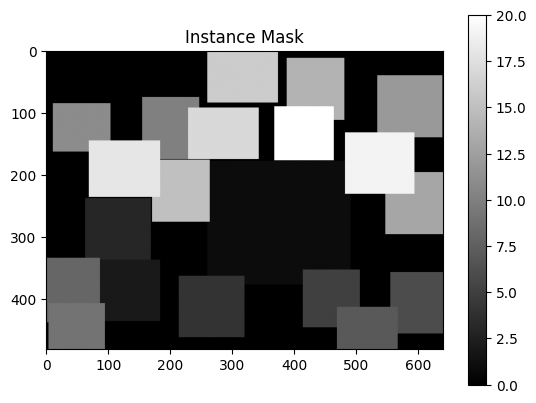

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

mask = cv2.imread(
    "/content/merged_BCCD/train/masks/IM_000001.png", 0
)

print("Unique values:", np.unique(mask))
print("Non-zero pixels:", np.count_nonzero(mask))

plt.imshow(mask, cmap="gray")
plt.title("Instance Mask")
plt.colorbar()
plt.show()


In [ ]:
import cv2
import numpy as np
from scipy import ndimage as ndi
import os

MASK_DIR = "/content/merged_BCCD/train/masks"
BOUNDARY_DIR = "/content/merged_BCCD/train/boundaries"
os.makedirs(BOUNDARY_DIR, exist_ok=True)

for mask_file in os.listdir(MASK_DIR):
    if not mask_file.endswith(".png"):
        continue

    mask = cv2.imread(os.path.join(MASK_DIR, mask_file), 0)
    boundary_map = np.zeros_like(mask, dtype=np.uint8)

    for inst_id in np.unique(mask):
        if inst_id == 0:
            continue
        inst_mask = (mask == inst_id).astype(np.uint8)

        # compute the boundary using morphological gradient
        kernel = np.ones((3,3), np.uint8)
        dilated = cv2.dilate(inst_mask, kernel, iterations=1)
        eroded = cv2.erode(inst_mask, kernel, iterations=1)
        boundary = dilated - eroded

        # add this instance's boundary to the boundary map
        boundary_map = np.maximum(boundary_map, boundary*255)

    out_file = mask_file.replace(".png", "_boundary.png")
    cv2.imwrite(os.path.join(BOUNDARY_DIR, out_file), boundary_map)


In [ ]:
import numpy as np
import cv2

bound = cv2.imread(
    "/content/merged_BCCD/train/boundaries/IM_000001_boundary.png", 0
)

print("Unique values:", np.unique(bound))
print("Non-zero pixels:", np.count_nonzero(bound))
print("Shape:", bound.shape)


Unique values: [  0 255]
Non-zero pixels: 12590
Shape: (480, 640)


In [ ]:
import cv2
import numpy as np
from scipy import ndimage as ndi
import os

MASK_DIR = "/content/merged_BCCD/test/masks"
BOUNDARY_DIR = "/content/merged_BCCD/test/boundaries"
os.makedirs(BOUNDARY_DIR, exist_ok=True)

for mask_file in os.listdir(MASK_DIR):
    if not mask_file.endswith(".png"):
        continue

    mask = cv2.imread(os.path.join(MASK_DIR, mask_file), 0)
    boundary_map = np.zeros_like(mask, dtype=np.uint8)

    for inst_id in np.unique(mask):
        if inst_id == 0:
            continue
        inst_mask = (mask == inst_id).astype(np.uint8)

        # compute the boundary using morphological gradient
        kernel = np.ones((3,3), np.uint8)
        dilated = cv2.dilate(inst_mask, kernel, iterations=1)
        eroded = cv2.erode(inst_mask, kernel, iterations=1)
        boundary = dilated - eroded

        # add this instance's boundary to the boundary map
        boundary_map = np.maximum(boundary_map, boundary*255)

    out_file = mask_file.replace(".png", "_boundary.png")
    cv2.imwrite(os.path.join(BOUNDARY_DIR, out_file), boundary_map)


In [ ]:
import numpy as np
import cv2

bound = cv2.imread(
    "/content/merged_BCCD/test/boundaries/A_BloodImage_00339_boundary.png", 0
)

print("Unique values:", np.unique(bound))
print("Non-zero pixels:", np.count_nonzero(bound))
print("Shape:", bound.shape)


Unique values: [  0 255]
Non-zero pixels: 12174
Shape: (480, 640)


In [ ]:
import cv2
import numpy as np
from scipy import ndimage as ndi
import os

MASK_DIR = "/content/merged_BCCD/val/masks"
BOUNDARY_DIR = "/content/merged_BCCD/val/boundaries"
os.makedirs(BOUNDARY_DIR, exist_ok=True)

for mask_file in os.listdir(MASK_DIR):
    if not mask_file.endswith(".png"):
        continue

    mask = cv2.imread(os.path.join(MASK_DIR, mask_file), 0)
    boundary_map = np.zeros_like(mask, dtype=np.uint8)

    for inst_id in np.unique(mask):
        if inst_id == 0:
            continue
        inst_mask = (mask == inst_id).astype(np.uint8)

        # compute the boundary using morphological gradient
        kernel = np.ones((3,3), np.uint8)
        dilated = cv2.dilate(inst_mask, kernel, iterations=1)
        eroded = cv2.erode(inst_mask, kernel, iterations=1)
        boundary = dilated - eroded

        # add this instance's boundary to the boundary map
        boundary_map = np.maximum(boundary_map, boundary*255)

    out_file = mask_file.replace(".png", "_boundary.png")
    cv2.imwrite(os.path.join(BOUNDARY_DIR, out_file), boundary_map)


In [ ]:
import numpy as np
import cv2

bound = cv2.imread(
    "/content/merged_BCCD/test/boundaries/A_BloodImage_00339_boundary.png", 0
)

print("Unique values:", np.unique(bound))
print("Non-zero pixels:", np.count_nonzero(bound))
print("Shape:", bound.shape)


Unique values: [  0 255]
Non-zero pixels: 12174
Shape: (480, 640)


In [ ]:
import albumentations as A
import tensorflow as tf
import numpy as np

# 1. Define the transform (Removed ToTensorV2 and fixed Normalize)
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.Affine(
        translate_percent=0.05,
        scale=(0.9, 1.1),
        rotate=0,
        p=0.5
    ),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
    # REMOVED Normalize and ToTensorV2 because TensorFlow handles these
    # during load_sample (dividing by 255) and expects HWC format.
])

def albumentations_augment(image, y):
    # image and y arrive as numpy arrays from tf.numpy_function
    data = {"image": image, "mask": y}
    aug_data = train_transform(**data)

    return aug_data["image"], aug_data["mask"]

def tf_augment(image, y):
    # This wrapper allows the numpy-based Albumentations to run in the TF graph
    aug_img, aug_y = tf.numpy_function(
        albumentations_augment,
        [image, y],
        [tf.float32, tf.float32]
    )

    # 2. Re-enforce the shapes for TensorFlow (H, W, C)
    aug_img.set_shape([256, 256, 3])
    aug_y.set_shape([256, 256, 3]) # This contains Mask, Dist, and Bound

    return aug_img, aug_y

In [ ]:
import tensorflow as tf

def encoder_block(inputs, num_filters):
    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(inputs)
    x = tf.keras.layers.BatchNormalization()(x) # Added for stability
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x) # Added for stability
    x = tf.keras.layers.Activation('relu')(x)

    p = tf.keras.layers.MaxPool2D((2,2))(x)
    return x, p

def decoder_block(inputs, skip_features, num_filters):
    x = tf.keras.layers.Conv2DTranspose(
        num_filters, (2,2), strides=2, padding='same'
    )(inputs)

    x = tf.keras.layers.Concatenate()([x, skip_features])

    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x) # Added for stability
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x) # Added for stability
    x = tf.keras.layers.Activation('relu')(x)

    return x

def unet_model(input_shape=(256, 256, 3)):
    inputs = tf.keras.layers.Input(input_shape)

    # Encoder
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    # Bridge
    b = tf.keras.layers.Conv2D(1024, 3, padding='same')(p4)
    b = tf.keras.layers.BatchNormalization()(b)
    b = tf.keras.layers.Activation('relu')(b)
    b = tf.keras.layers.Conv2D(1024, 3, padding='same')(b)
    b = tf.keras.layers.BatchNormalization()(b)
    b = tf.keras.layers.Activation('relu')(b)

    # Decoder
    d1 = decoder_block(b, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    # Head 1: Mask
    mask_out = tf.keras.layers.Conv2D(1, 1, activation='sigmoid', name='mask_head')(d4)

    # Head 2: Distance (ReLU is correct, but we'll force it to learn with loss weights)
    dist_out = tf.keras.layers.Conv2D(1, 1, activation='relu', name='dist_head')(d4)

    # Head 3: Boundary
    bound_out = tf.keras.layers.Conv2D(1, 1, activation='sigmoid', name='bound_head')(d4)

    outputs = tf.keras.layers.Concatenate()([mask_out, dist_out, bound_out])
    return tf.keras.Model(inputs, outputs)
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred)
    denominator = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)

    dice = (2.0 * intersection + smooth) / (denominator + smooth)
    return 1.0 - dice
def total_loss(y_true, y_pred):
    mask_true  = y_true[..., 0]
    dist_true  = y_true[..., 1]
    bound_true = y_true[..., 2]

    mask_pred  = y_pred[..., 0]
    dist_pred  = y_pred[..., 1]
    bound_pred = y_pred[..., 2]

    # Mask Loss
    l_mask = dice_loss(mask_true, mask_pred)

    # Distance Loss - Multiplier increased to 15.0 to recover the 'collapsed' head
    l_dist = tf.keras.losses.MeanSquaredError()(dist_true, dist_pred) * 15.0

    # Boundary Loss - Multiplier increased to 2.0 to maintain the sharp lines you achieved
    l_bound = tf.keras.losses.BinaryCrossentropy(from_logits=False)(bound_true, bound_pred) * 2.0

    return l_mask + l_dist + l_bound

In [ ]:
import tensorflow as tf
import os

def load_image(path, gray=False):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=1 if gray else 3)
    img = tf.cast(img, tf.float32)
    return img

def load_npy(path):
    # tf.py_function expects a list of inputs and returns a list of outputs
    # The path will be passed as a tf.Tensor of type string (bytes).
    def _load_npy_np(p):
        # Ensure p is a Python bytes object before decoding
        # p is expected to be a tf.Tensor of string dtype, so .numpy() extracts the bytes
        path_str = p.numpy().decode('utf-8')
        return np.load(path_str).astype(np.float32)

    # Wrap the numpy load operation in tf.py_function
    return tf.py_function(_load_npy_np, [path], tf.float32)

def load_sample(img_path, mask_path, dist_path, bound_path, augment=False):
    # 1. Load and Resize Image
    image = tf.io.read_file(img_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, (256, 256))
    image = tf.cast(image, tf.float32) / 255.0

    # 2. Load and Resize Mask (binary foreground)
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, (256, 256), method="nearest")
    mask = tf.cast(mask > 0, tf.float32)

    # 3. Load and Resize Distance map (NPY)
    dist = load_npy(dist_path)
    dist = tf.expand_dims(dist, axis=-1)

    # FIX: Use [None, None, 1] to allow dynamic input sizes from different datasets
    dist.set_shape([None, None, 1])

    dist = tf.image.resize(dist, (256, 256))
    dist = tf.squeeze(dist, axis=-1) # Back to (256, 256)

    # 4. Load and Resize Boundary
    boundary = tf.io.read_file(bound_path)
    boundary = tf.image.decode_png(boundary, channels=1)
    boundary = tf.image.resize(boundary, (256, 256), method="nearest")
    boundary = tf.cast(boundary > 0, tf.float32)

    # 5. Stack Ground Truth: (H, W, 3)
    y = tf.stack(
        [mask[..., 0], dist, boundary[..., 0]],
        axis=-1
    )

    # 6. Final Shape Enforcement
    # This helps the model training loop confirm the dimensions
    image.set_shape([256, 256, 3])
    y.set_shape([256, 256, 3])

    return image, y

In [ ]:
def create_dataset(root_dir, batch_size=4, shuffle=True, augment=False):
    img_dir = os.path.join(root_dir, "images")
    mask_dir = os.path.join(root_dir, "masks")
    dist_dir = os.path.join(root_dir, "distances")
    bound_dir = os.path.join(root_dir, "boundaries")

    image_files = sorted(os.listdir(img_dir))
    img_paths, mask_paths, dist_paths, bound_paths = [], [], [], []

    for f in image_files:
        base = os.path.splitext(f)[0]
        img_paths.append(os.path.join(img_dir, f))
        mask_paths.append(os.path.join(mask_dir, base + ".png"))
        dist_paths.append(os.path.join(dist_dir, base + "_dist.npy"))
        bound_paths.append(os.path.join(bound_dir, base + "_boundary.png"))

    ds = tf.data.Dataset.from_tensor_slices(
        (img_paths, mask_paths, dist_paths, bound_paths)
    )

    # 1. Load the data
    ds = ds.map(
        lambda i, m, d, b: load_sample(i, m, d, b), # remove augment from here
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # 2. Apply Augmentation ONLY if augment is True
    # This is where your Albumentations logic gets triggered
    if augment:
        ds = ds.map(tf_augment, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(len(img_paths)) # Better to shuffle by full dataset size

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [ ]:
train_ds = create_dataset(
    "/content/merged_BCCD/train",
    batch_size=4,
    augment=True
)

val_ds = create_dataset(
    "/content/merged_BCCD/val",
    batch_size=4,
    shuffle=False,
    augment=False
)

test_ds = create_dataset(
    "/content/merged_BCCD/test",
    batch_size=1,
    shuffle=False,
    augment=False
)


In [ ]:
# 1. Re-compile the model (Ensuring we use a clean optimizer state)
model = unet_model(input_shape=(256, 256, 3))
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=total_loss
)

# 2. Define Professional Callbacks
callbacks = [
    # Reduce learning rate when validation loss plateaus
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,        # Reduce LR by 5x (e.g., 1e-4 -> 2e-5)
        patience=5,         # Number of epochs with no improvement before reducing
        min_lr=1e-7,       # Don't go below this
        verbose=1
    ),

    # Save the absolute best model found during the 50 epochs
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_unet_bccd.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),

    # Optional: Stop training if the model stops improving for 15 epochs
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
]

# 3. Start the 50-Epoch Marathon
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,             # Increased to your target
    callbacks=callbacks    # Added the new logic here
)

# Final Save (Note: 'best_unet_bccd.keras' will be more accurate than this one)
model.save("unet_bccd_final_50eps.keras")

Epoch 1/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - loss: 2.2339
Epoch 1: val_loss improved from inf to 1.94742, saving model to best_unet_bccd.keras
127/127 ━━━━━━━━━━━━━━━━━━━━ 174s 854ms/step - loss: 2.2303 - val_loss: 1.9474 - learning_rate: 1.0000e-04
Epoch 2/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - loss: 1.1994
Epoch 2: val_loss improved from 1.94742 to 1.63736, saving model to best_unet_bccd.keras
127/127 ━━━━━━━━━━━━━━━━━━━━ 50s 344ms/step - loss: 1.1990 - val_loss: 1.6374 - learning_rate: 1.0000e-04
Epoch 3/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - loss: 1.0064
Epoch 3: val_loss improved from 1.63736 to 1.36425, saving model to best_unet_bccd.keras
127/127 ━━━━━━━━━━━━━━━━━━━━ 52s 360ms/step - loss: 1.0061 - val_loss: 1.3643 - learning_rate: 1.0000e-04
Epoch 4/5
127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - loss: 0.8817
Epoch 4: val_loss improved from 1.36425 to 1.13890, saving model to best_unet_bccd.keras
127/127 ━━━━━━━━━━━━━━━━━━━━ 48s 339ms/step - loss: 0.881

In [ ]:
def get_ids(root):
    return set([
        os.path.splitext(f)[0]
        for f in os.listdir(os.path.join(root, "images"))
    ])

train_ids = get_ids("/content/merged_BCCD/train")
val_ids   = get_ids("/content/merged_BCCD/val")
test_ids  = get_ids("/content/merged_BCCD/test")

print("Train ∩ Val:", len(train_ids & val_ids))
print("Train ∩ Test:", len(train_ids & test_ids))
print("Val ∩ Test:", len(val_ids & test_ids))


Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


In [ ]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])
    inter = tf.reduce_sum(y_true * y_pred)
    return (2. * inter + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )


In [ ]:
mask_dices = []
boundary_dices = []
dist_maes = []

for x, y_true in test_ds:
    y_pred = model(x, training=False)

    # Sigmoid ONLY for metrics
    mask_pred = tf.nn.sigmoid(y_pred[..., 0]) > 0.5
    bound_pred = tf.nn.sigmoid(y_pred[..., 2]) > 0.5

    mask_true = y_true[..., 0]
    bound_true = y_true[..., 2]
    dist_true = y_true[..., 1]
    dist_pred = y_pred[..., 1]

    mask_dices.append(
        dice_coef(mask_true, tf.cast(mask_pred, tf.float32)).numpy()
    )
    boundary_dices.append(
        dice_coef(bound_true, tf.cast(bound_pred, tf.float32)).numpy()
    )
    dist_maes.append(
        tf.reduce_mean(tf.abs(dist_true - dist_pred)).numpy()
    )

print("Mask Dice:", np.mean(mask_dices))
print("Boundary Dice:", np.mean(boundary_dices))
print("Distance MAE:", np.mean(dist_maes))


Mask Dice: 0.66680956
Boundary Dice: 0.06114756
Distance MAE: 0.07762749


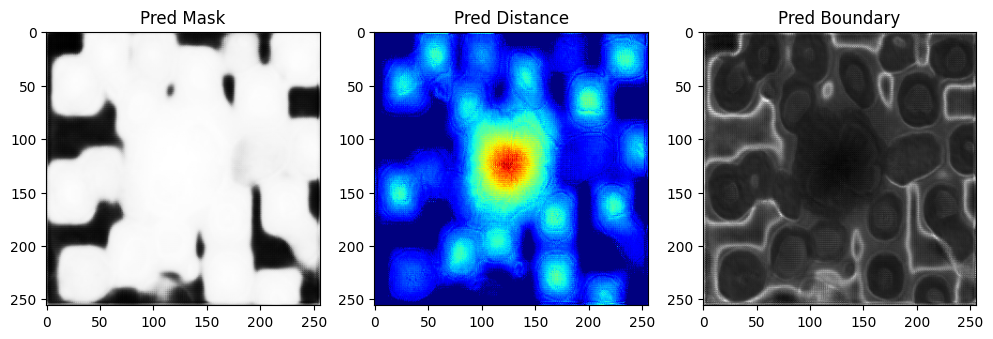

In [ ]:
x, y = next(iter(test_ds))
pred = model(x, training=False)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Pred Mask")
plt.imshow(tf.nn.sigmoid(pred[0,...,0]), cmap="gray")

plt.subplot(1,3,2)
plt.title("Pred Distance")
plt.imshow(pred[0,...,1], cmap="jet")

plt.subplot(1,3,3)
plt.title("Pred Boundary")
plt.imshow(tf.nn.sigmoid(pred[0,...,2]), cmap="gray")

plt.show()


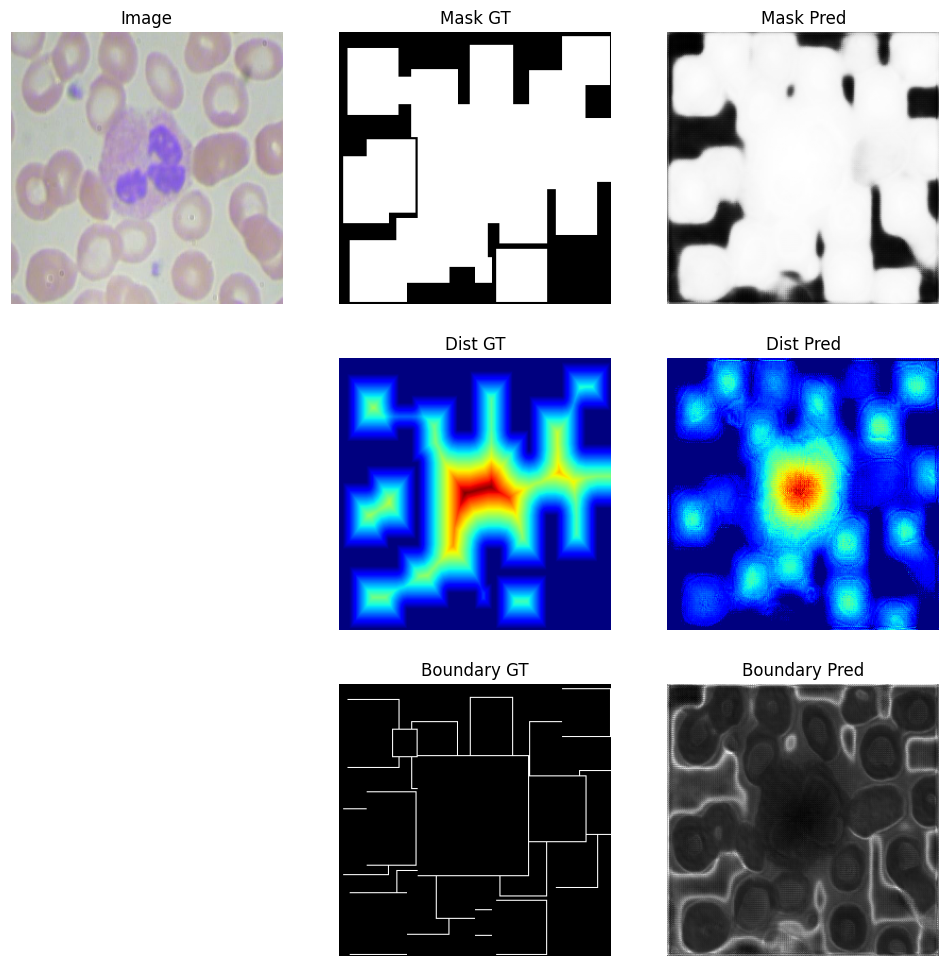

In [ ]:
import matplotlib.pyplot as plt

for x, y_true in test_ds.take(1):
    y_pred = model(x, training=False)

    image = x[0].numpy()
    mask_gt = y_true[0,...,0].numpy()
    dist_gt = y_true[0,...,1].numpy()
    bound_gt = y_true[0,...,2].numpy()

    mask_pr = tf.nn.sigmoid(y_pred[0,...,0]).numpy()
    dist_pr = y_pred[0,...,1].numpy()
    bound_pr = tf.nn.sigmoid(y_pred[0,...,2]).numpy()

    fig, axs = plt.subplots(3, 3, figsize=(12,12))

    axs[0,0].imshow(image)
    axs[0,0].set_title("Image")

    axs[0,1].imshow(mask_gt, cmap='gray')
    axs[0,1].set_title("Mask GT")

    axs[0,2].imshow(mask_pr, cmap='gray')
    axs[0,2].set_title("Mask Pred")

    axs[1,1].imshow(dist_gt, cmap='jet')
    axs[1,1].set_title("Dist GT")

    axs[1,2].imshow(dist_pr, cmap='jet')
    axs[1,2].set_title("Dist Pred")

    axs[2,1].imshow(bound_gt, cmap='gray')
    axs[2,1].set_title("Boundary GT")

    axs[2,2].imshow(bound_pr, cmap='gray')
    axs[2,2].set_title("Boundary Pred")

    for ax in axs.flatten():
        ax.axis("off")

    plt.show()


In [ ]:
print("The model identifies biological cell structures well, but the rectangular ground truth creates a significant shape mismatch with the actual round cells. While the distance predictions correctly highlight cell centers, the boundary outputs suffer from checkerboard artifacts and fuzzy edges. This suggests the model is attempting to generalize to organic shapes despite being trained on rigid, boxy labels. To improve accuracy, the ground truth should be refined to follow the natural circular contours of the blood cells.")

The model identifies biological cell structures well, but the rectangular ground truth creates a significant shape mismatch with the actual round cells. While the distance predictions correctly highlight cell centers, the boundary outputs suffer from checkerboard artifacts and fuzzy edges. This suggests the model is attempting to generalize to organic shapes despite being trained on rigid, boxy labels. To improve accuracy, the ground truth should be refined to follow the natural circular contours of the blood cells.
